# Testing generalized code with 2 states

Same states as before, new code

## **Part 1** Simulating and plotting data

### Simulating data

In [2]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from methods.hmm_ar_1_k_states import (
    simulate_rs_ar1,
    transform_params,
    obs_density,
    forward_algorithm,
    neg_loglik,
    fit_model,
    filtered_probs
)

from methods.plotting import set_style
set_style()

In [3]:
T = 1000
seed = 1
# AR(1) parameters
beta = np.array([0.2, 0.8])
sigma = np.array([0.5, 1.0])

# transition matrix
P = np.array([
    [0.95, 0.05],
    [0.05, 0.95]
])



y, states = simulate_rs_ar1(T=T, beta=beta, sigma=sigma, P=P, seed=seed)

print("")

### Plotting the simulated AR(1) series

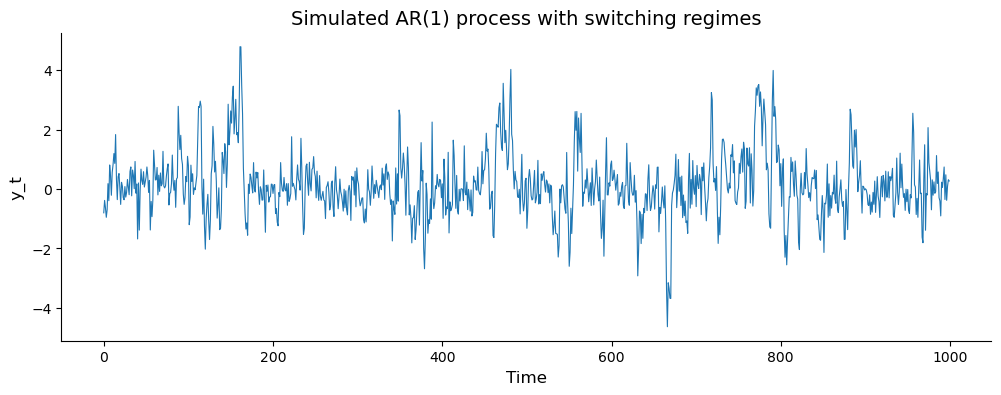

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(y)
plt.title("Simulated AR(1) process with switching regimes")
plt.xlabel("Time")
plt.ylabel("y_t")
plt.savefig("../plots/simulated_time_series_2_states.pdf", bbox_inches="tight", format="pdf")
plt.show()

### Plotting the hidden states

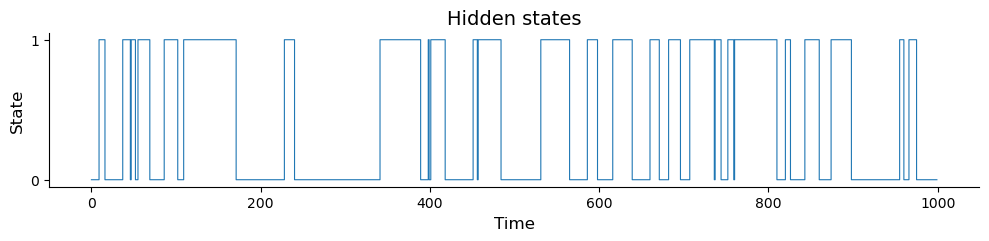

In [6]:
plt.figure(figsize=(12,2))
plt.step(range(T), states, where="post")
plt.title("Hidden states")
plt.xlabel("Time")
plt.ylabel("State")
plt.yticks([0,1])
plt.show()

### Combined plot

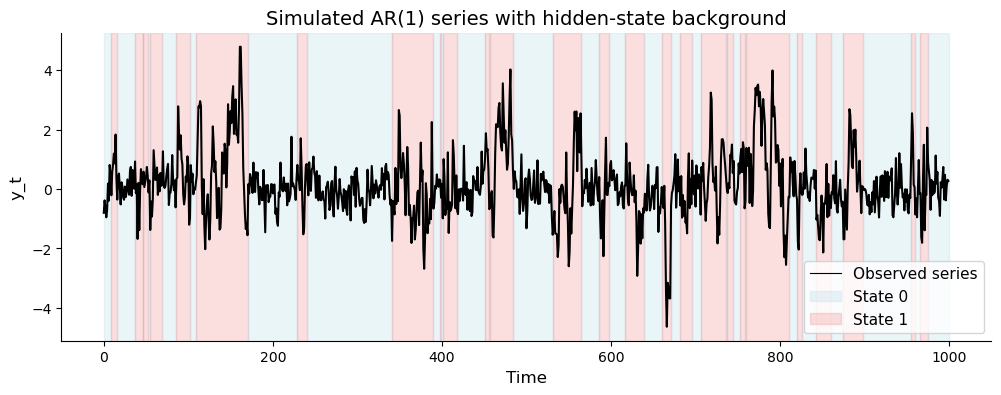

In [8]:
import matplotlib.patches as mpatches

state_colors = {
    0: "lightblue",
    1: "lightcoral"
}

plt.figure(figsize=(12, 4))
plt.plot(y, color="black", linewidth=1.5, label="Observed series")

start = 0
current_state = states[0]

for t in range(1, T):
    if states[t] != current_state:
        plt.axvspan(start, t, color=state_colors[current_state], alpha=0.25)
        start = t
        current_state = states[t]

plt.axvspan(start, T, color=state_colors[current_state], alpha=0.25)

legend_patches = [
    mpatches.Patch(color=state_colors[0], alpha=0.25, label="State 0"),
    mpatches.Patch(color=state_colors[1], alpha=0.25, label="State 1")
]

plt.legend(handles=[plt.Line2D([0], [0], color="black", label="Observed series")] + legend_patches)
plt.title("Simulated AR(1) series with hidden-state background")
plt.xlabel("Time")
plt.ylabel("y_t")
plt.savefig("../plots/simulated_time_series_2_states_with_state_background.pdf", bbox_inches="tight", format="pdf")

plt.show()

### Simulation of a Regime-Switching AR(1) Process, summary

The code simulates a time series generated by an **AR(1) process whose parameters depend on an unobserved (hidden) state**. The hidden state evolves according to a **two-state Markov chain**.

First, two sets of AR(1) parameters are defined. Each state has its own autoregressive coefficient \( $\rho$ \) and innovation standard deviation \( $\sigma$ \). A **transition matrix** specifies the probability of switching between the two states at each time step.

The simulation proceeds recursively for \(T = 500\) observations. At each time step:

1. The next hidden state is drawn using the transition probabilities of the Markov chain.
2. Conditional on the current state, the observation is generated from the corresponding AR(1) model:
$$
y_t = \rho_s y_{t-1} + \varepsilon_t, \quad \varepsilon_t \sim N(0, \sigma_s^2)
$$

This produces two sequences:
- `states`: the simulated hidden regimes
- `y`: the observed time series

After running the simulation, the resulting AR(1) series is plotted. The background of the plot is shaded according to the hidden state, making it possible to visually identify the periods in which the process is governed by each regime.

## **Part 2** Estimate parameters using MLE and forward algorithm

### Estimate parameters

In [9]:
# Initial guess:
# [b1, b2, eta1, eta2, a1, a2]
beta0 = np.array([0.0, 0.5])
sigma0 = np.array([-0.5, 0.0])
P0 = np.array([[2.0, 0.0],
               [0.0, 2.0]])
# theta0 = np.array([
#     0.0,
#     0.5,
#     -0.5,
#     0.0,
#     2.0,
#     2.0])

# Estimate model:
result, params_hat = fit_model(y, beta0, sigma0, P0)

# Print optimization info:
print("Converged:", result.success)

# Compare estimates with true parameters:
true_params = {
    "beta1": beta[0],
    "beta2": beta[1],
    "sigma1": sigma[0],
    "sigma2": sigma[1],
    "p11": P[0, 0],
    "p22": P[1, 1],
    "p12": P[0, 1],
    "p21": P[1, 0]
}

pred_params = {
    "beta1": params_hat["beta"][0],
    "beta2": params_hat["beta"][1],
    "sigma1": params_hat["sigma"][0],
    "sigma2": params_hat["sigma"][1],
    "p11": params_hat["P"][0, 0],
    "p22": params_hat["P"][1, 1],
    "p12": params_hat["P"][0, 1],
    "p21": params_hat["P"][1, 0]
}
comparison = pd.DataFrame({
    "true": true_params,
    "estimated": pred_params
})
print("\nComparison table:")
# print(true_params)
# print(params_hat)
# print(pred_params)
print(comparison)




Converged: True

Comparison table:
        true  estimated
beta1   0.20   0.165026
beta2   0.80   0.791064
sigma1  0.50   0.512389
sigma2  1.00   0.967119
p11     0.95   0.953584
p22     0.95   0.939530
p12     0.05   0.046416
p21     0.05   0.060470


Comparing the true and simulated states, last 500 observations

In [10]:
n_plot = 500
idx = slice(-n_plot, None)
y_plot = y[idx]
states_plot = states[idx]
alpha_hat, _, _ = forward_algorithm(
    y=y,
    beta=params_hat["beta"],
    sigma=params_hat["sigma"],
    P = params_hat["P"]
)
probs_hat = filtered_probs(alpha_hat)
probs_plot = probs_hat[idx]

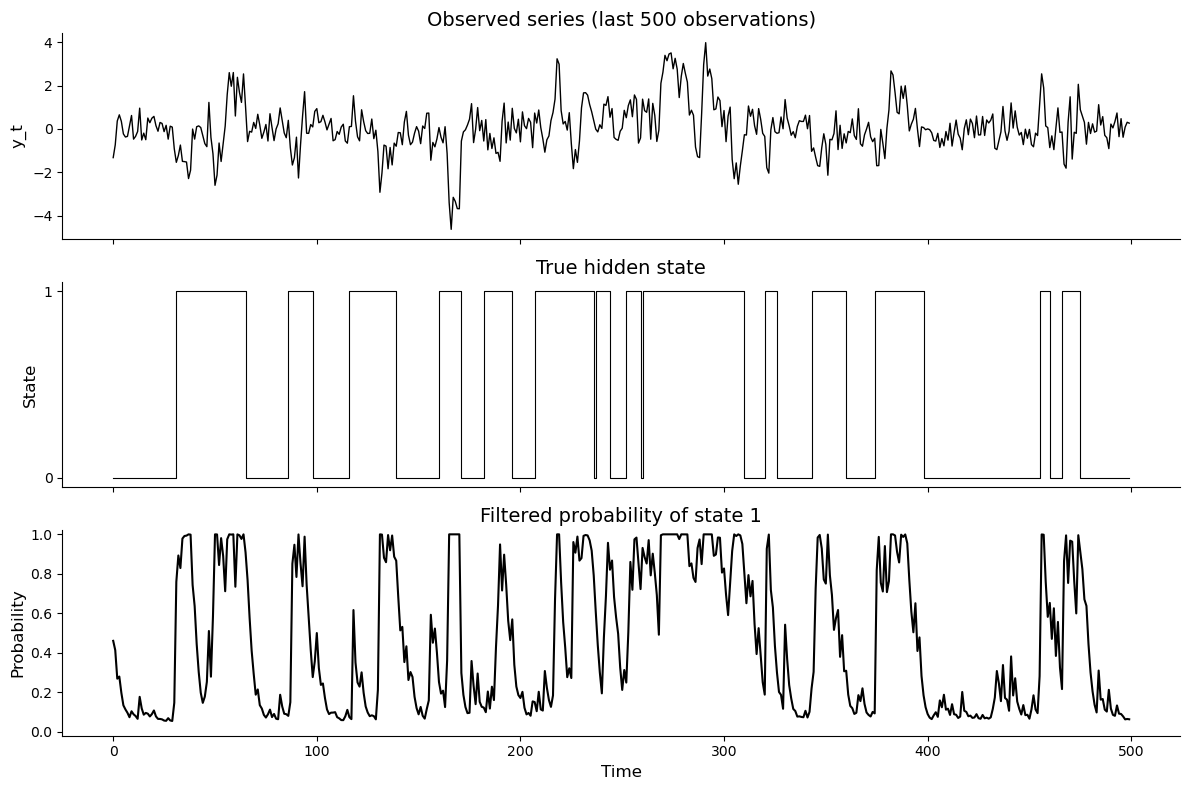

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Observed series
axes[0].plot(y_plot, color="black", linewidth=1)
axes[0].set_title("Observed series (last 500 observations)")
axes[0].set_ylabel("y_t")

# True hidden state
axes[1].step(range(n_plot), states_plot, where="post", color="black")
axes[1].set_title("True hidden state")
axes[1].set_ylabel("State")
axes[1].set_yticks([0, 1])

# Filtered probability
axes[2].plot(probs_plot[:, 1], color="black", linewidth=1.5)
axes[2].set_title("Filtered probability of state 1")
axes[2].set_ylabel("Probability")
axes[2].set_xlabel("Time")
axes[2].set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.savefig("../plots/simulated_2_states_with_predicted_states_seperate_figs.pdf", bbox_inches="tight", format="pdf")

plt.show()

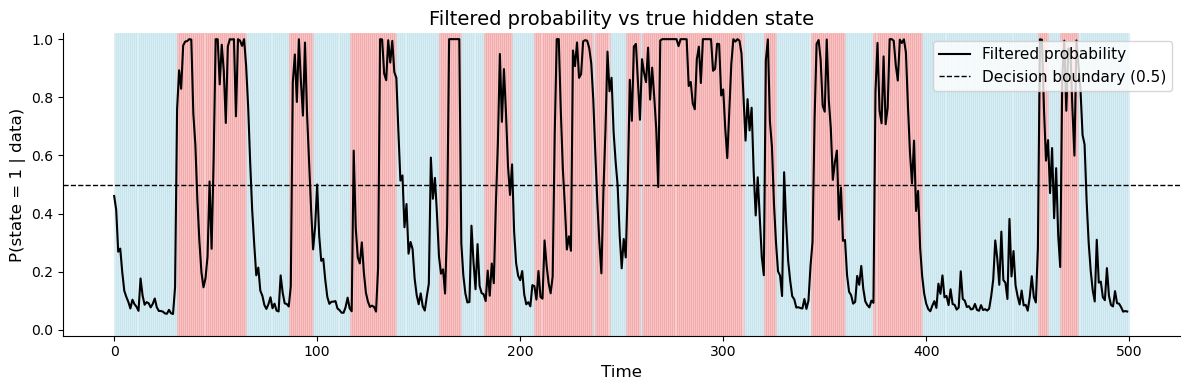

In [14]:
fig, ax = plt.subplots(figsize=(12,4))

# Background shading for true states
for t in range(n_plot):
    if states_plot[t] == 1:
        ax.axvspan(t, t+1, color="lightcoral", alpha=0.3)
    else:
        ax.axvspan(t, t+1, color="lightblue", alpha=0.3)

# Filtered probability
ax.plot(probs_plot[:,1], color="black", linewidth=1.5, label="Filtered probability")

# Decision boundary
ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label="Decision boundary (0.5)")

ax.set_ylabel("P(state = 1 | data)")
ax.set_xlabel("Time")
ax.set_ylim(-0.02, 1.02)
ax.set_title("Filtered probability vs true hidden state")

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend()

plt.tight_layout()
plt.savefig("../plots/simulated_time_series_2_states_pred_state.pdf", bbox_inches="tight", format="pdf")

plt.show()

Now, using the 0.5 decision boundary:

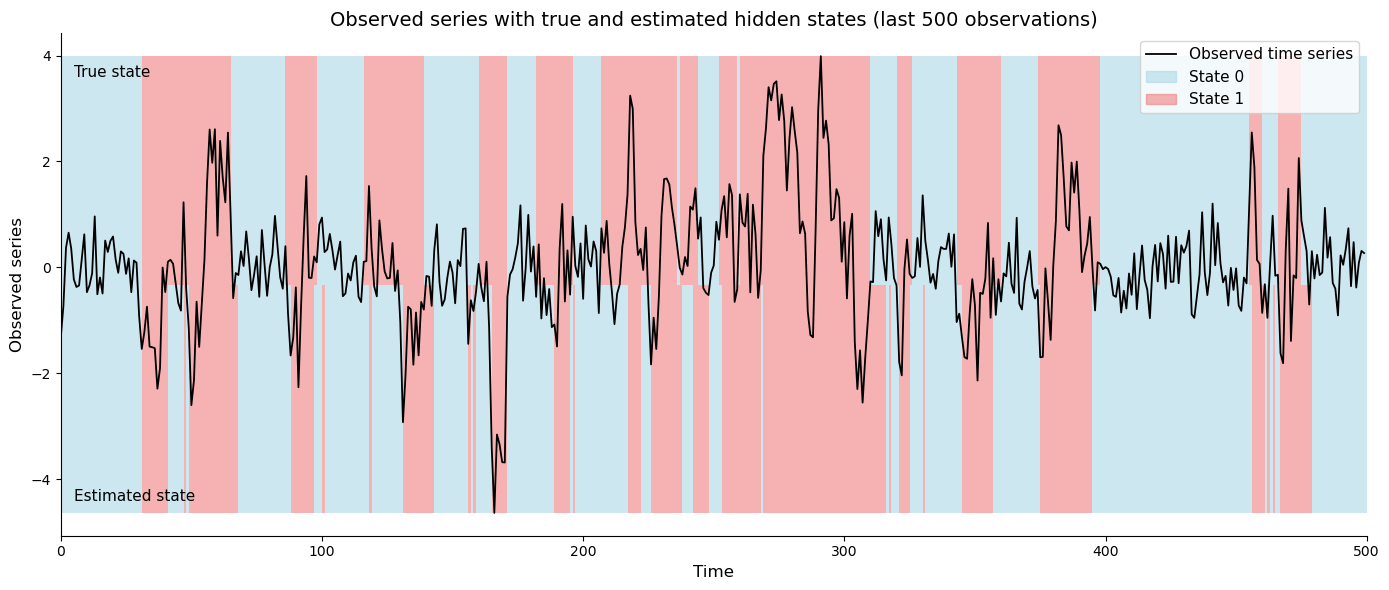

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Last 500 observations
n_plot = 500
idx = slice(-n_plot, None)

y_plot = y[idx]
states_true = states[idx]
probs_plot = probs_hat[idx]

# Hard classification using decision boundary
states_est = (probs_plot[:, 1] > 0.5).astype(int)

fig, ax = plt.subplots(figsize=(14, 6))

# Plot observed time series
ax.plot(y_plot, color="black", linewidth=1.3, label="Observed time series", zorder=3)

# Determine vertical limits
ymin, ymax = y_plot.min(), y_plot.max()
y_mid = 0.5 * (ymin + ymax)

# Shade TRUE states (top half)
for t in range(n_plot):
    color_true = "lightcoral" if states_true[t] == 1 else "lightblue"
    ax.fill_between([t, t+1], y_mid, ymax, color=color_true, alpha=0.6, linewidth=0)

# Shade ESTIMATED states (bottom half)
for t in range(n_plot):
    color_est = "lightcoral" if states_est[t] == 1 else "lightblue"
    ax.fill_between([t, t+1], ymin, y_mid, color=color_est, alpha=0.6, linewidth=0)

# Labels
ax.text(5, ymax - 0.02*(ymax-ymin), "True state", fontsize=11, va="top")
ax.text(5, ymin + 0.02*(ymax-ymin), "Estimated state", fontsize=11, va="bottom")

# Formatting
ax.set_xlim(0, n_plot)
ax.set_xlabel("Time")
ax.set_ylabel("Observed series")
ax.set_title("Observed series with true and estimated hidden states (last 500 observations)")

# Legend
line_handle = plt.Line2D([0], [0], color="black", linewidth=1.3, label="Observed time series")
state0_patch = mpatches.Patch(color="lightblue", alpha=0.6, label="State 0")
state1_patch = mpatches.Patch(color="lightcoral", alpha=0.6, label="State 1")

ax.legend(handles=[line_handle, state0_patch, state1_patch], loc="upper right")

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../plots/simulated_2_states_pred_and_true_states.pdf", bbox_inches="tight", format="pdf")

plt.show()

### Misclassification plot

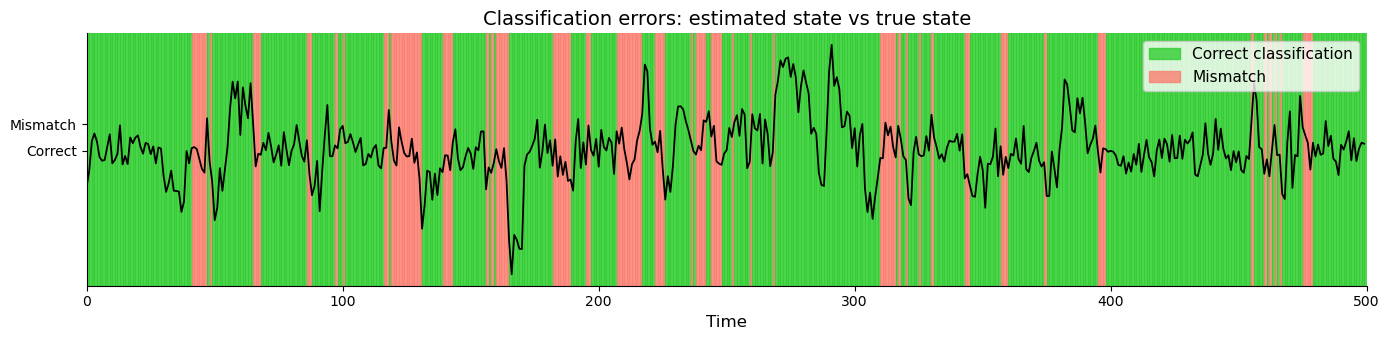

In [17]:
# Indicator for classification error
state_mismatch = (states_true != states_est).astype(int)

fig, ax = plt.subplots(figsize=(14, 3.5))

# Background shading: mismatch vs correct classification
for t in range(n_plot):
    color = "salmon" if state_mismatch[t] == 1 else "limegreen"
    ax.axvspan(t, t + 1, color=color, alpha=0.8)

# Plot observed time series
ax.plot(y_plot, color="black", linewidth=1.3, label="Observed time series", zorder=3)

ax.set_xlim(0, n_plot)
# ax.set_ylim(-0.05, 1.05)
ax.set_yticks([0, 1])
ax.set_yticklabels(["Correct", "Mismatch"])
ax.set_xlabel("Time")
ax.set_title("Classification errors: estimated state vs true state")

# Legend
correct_patch = mpatches.Patch(color="limegreen", alpha=0.8, label="Correct classification")
mismatch_patch = mpatches.Patch(color="salmon", alpha=0.8, label="Mismatch")

ax.legend(handles=[correct_patch, mismatch_patch], loc="upper right")

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../plots/simulated_2_states_misclassification_plot.pdf", bbox_inches="tight", format="pdf")

plt.show()

# Testing code with 3 states

## Simulation:

In [18]:
T = 1000
seed = 1
# AR(1) parameters
beta = np.array([0.2, 0.8, 0.5])
sigma = np.array([0.5, 1.0, 0.1])

# transition matrix
P = np.array([
    [0.85, 0.10, 0.05],
    [0.15, 0.75, 0.10],
    [0.05, 0.20, 0.75]
])


y, states = simulate_rs_ar1(T=T, beta=beta, sigma=sigma, P=P, seed=seed)

print("")

### Plot simulation

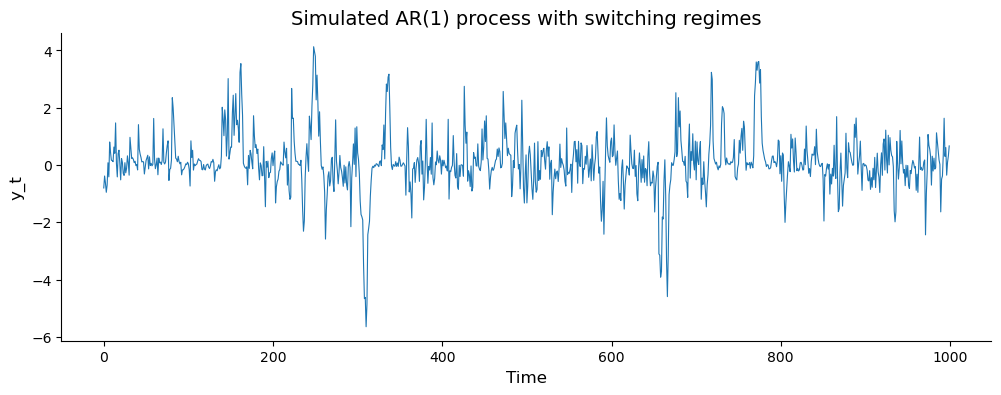

In [20]:
plt.figure(figsize=(12,4))
plt.plot(y)
plt.title("Simulated AR(1) process with switching regimes")
plt.xlabel("Time")
plt.ylabel("y_t")
plt.savefig("../plots/simulated_time_series_3_states.pdf", bbox_inches="tight", format="pdf")

plt.show()

### Plot hidden states:

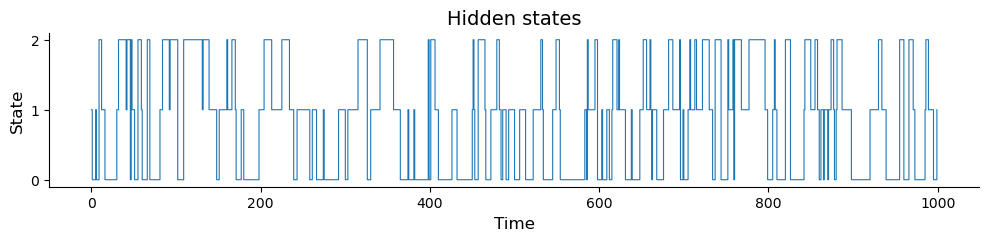

In [22]:
plt.figure(figsize=(12,2))
plt.step(range(T), states, where="post")
plt.title("Hidden states")
plt.xlabel("Time")
plt.ylabel("State")
plt.yticks([0,1,2])
plt.savefig("../plots/simulated_states_3_states.pdf", bbox_inches="tight", format="pdf")

plt.show()

### Combined plot:

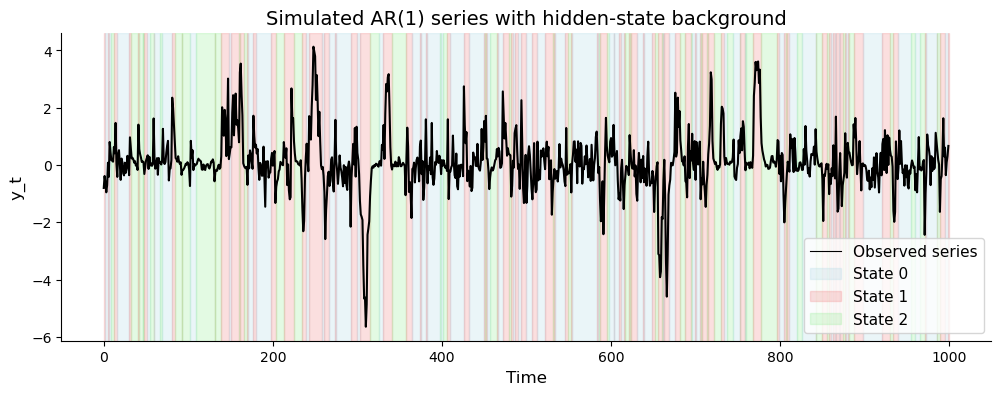

In [24]:
state_colors = {
    0: "lightblue",
    1: "lightcoral",
    2: "lightgreen"
}

plt.figure(figsize=(12, 4))
plt.plot(y, color="black", linewidth=1.5, label="Observed series")

start = 0
current_state = states[0]

for t in range(1, T):
    if states[t] != current_state:
        plt.axvspan(start, t, color=state_colors[current_state], alpha=0.25)
        start = t
        current_state = states[t]

plt.axvspan(start, T, color=state_colors[current_state], alpha=0.25)

legend_patches = [
    mpatches.Patch(color=state_colors[0], alpha=0.25, label="State 0"),
    mpatches.Patch(color=state_colors[1], alpha=0.25, label="State 1"),
    mpatches.Patch(color=state_colors[2], alpha=0.25, label="State 2")
]

plt.legend(handles=[plt.Line2D([0], [0], color="black", label="Observed series")] + legend_patches)
plt.title("Simulated AR(1) series with hidden-state background")
plt.xlabel("Time")
plt.ylabel("y_t")
plt.savefig("../plots/simulated_3_states_state_backgrounds.pdf", bbox_inches="tight", format="pdf")

plt.show()

## Estimate parameters

In [25]:
# Initial guess:
beta0 = np.array([0.0, 0.5, 0.1])
sigma0 = np.array([-0.5, 0.0, 0.1])
P0 = np.array([[2.0, 0.0, 1.0],
               [0.0, 2.0, 1.2],
               [2.0, 1.0, 1.0]])

# Estimate model:
result, params_hat = fit_model(y, beta0, sigma0, P0)

# Print optimization info:
print("Converged:", result.success)






Converged: True


In [26]:
# Compare estimates with true parameters:
true_params = {
    "beta": beta,
    "sigma": sigma,
    "P": P
}

pred_params = {
    "beta": params_hat["beta"],
    "sigma": params_hat["sigma"],
    "P": params_hat["P"]
}

comparison = pd.DataFrame({
    "true": true_params,
    "estimated": pred_params
})
print("\nComparison table:")
# print(true_params)
# print(params_hat)
# print(pred_params)
display(comparison)


Comparison table:


,true,estimated
beta,"[0.2, 0.8, 0.5]","[0.4994392641360029, 0.8500747135245488, 0.268..."
sigma,"[0.5, 1.0, 0.1]","[0.0984251086271354, 1.0642527209641515, 0.588..."
P,"[[0.85, 0.1, 0.05], [0.15, 0.75, 0.1], [0.05, ...","[[0.7828033237869997, 0.12204640851738145, 0.0..."


# Testing with 4 states

## Simulation

In [27]:
T = 1000
seed = 1
# AR(1) parameters
beta = np.array([-0.3, 0.0, 0.4, 0.8])

sigma = np.array([0.3, 0.6, 1.0, 0.2])

P = np.array([
    [0.90, 0.05, 0.03, 0.02],
    [0.10, 0.80, 0.05, 0.05],
    [0.05, 0.10, 0.80, 0.05],
    [0.02, 0.03, 0.05, 0.90]
])


y, states = simulate_rs_ar1(T=T, beta=beta, sigma=sigma, P=P, seed=seed)

print("")

### Plot simulation

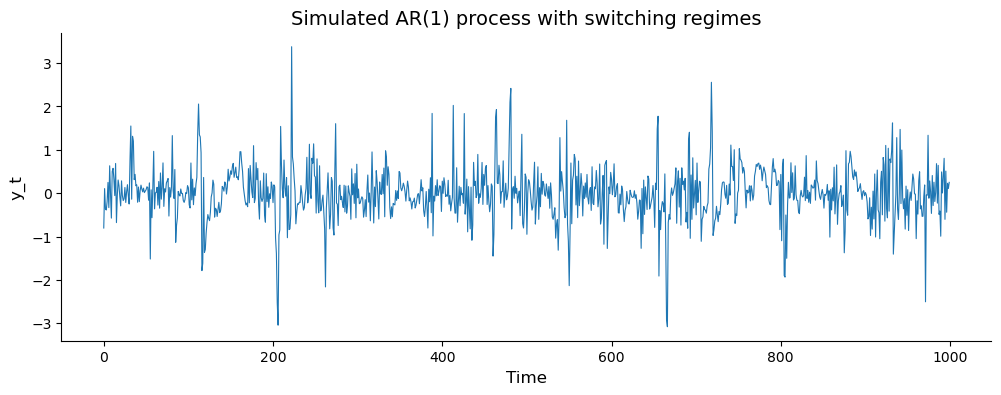

In [29]:
plt.figure(figsize=(12,4))
plt.plot(y)
plt.title("Simulated AR(1) process with switching regimes")
plt.xlabel("Time")
plt.ylabel("y_t")
plt.savefig("../plots/simulated_time_series_4_states.pdf", bbox_inches="tight", format="pdf")

plt.show()

### Plot hidden states

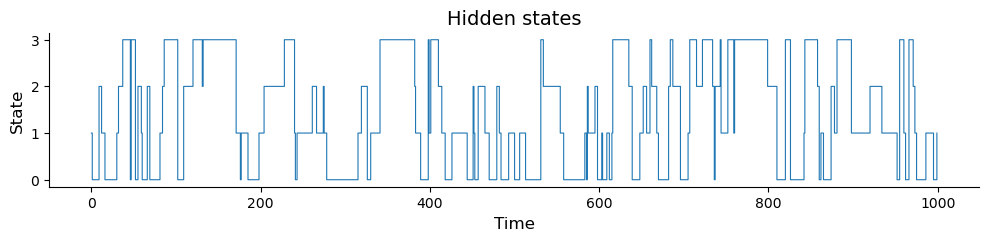

In [31]:
plt.figure(figsize=(12,2))
plt.step(range(T), states, where="post")
plt.title("Hidden states")
plt.xlabel("Time")
plt.ylabel("State")
plt.yticks([0,1,2,3])
plt.savefig("../plots/simulated_states_3_states.pdf", bbox_inches="tight", format="pdf")

plt.show()

### Combined plot

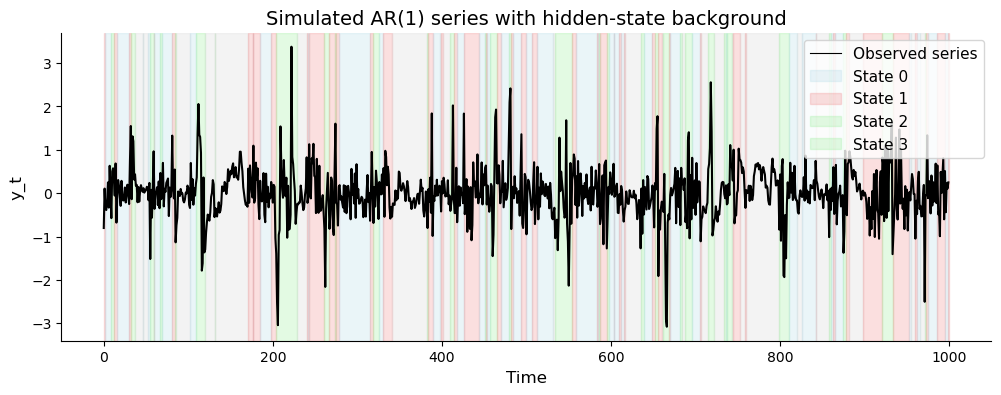

In [32]:
state_colors = {
    0: "lightblue",
    1: "lightcoral",
    2: "lightgreen",
    3: "lightgrey"
}

plt.figure(figsize=(12, 4))
plt.plot(y, color="black", linewidth=1.5, label="Observed series")

start = 0
current_state = states[0]

for t in range(1, T):
    if states[t] != current_state:
        plt.axvspan(start, t, color=state_colors[current_state], alpha=0.25)
        start = t
        current_state = states[t]

plt.axvspan(start, T, color=state_colors[current_state], alpha=0.25)

legend_patches = [
    mpatches.Patch(color=state_colors[0], alpha=0.25, label="State 0"),
    mpatches.Patch(color=state_colors[1], alpha=0.25, label="State 1"),
    mpatches.Patch(color=state_colors[2], alpha=0.25, label="State 2"),
    mpatches.Patch(color=state_colors[2], alpha=0.25, label="State 3")
]

plt.legend(handles=[plt.Line2D([0], [0], color="black", label="Observed series")] + legend_patches)
plt.title("Simulated AR(1) series with hidden-state background")
plt.xlabel("Time")
plt.ylabel("y_t")
plt.savefig("../plots/simulated_time_series_4_states_combined_plot.pdf", bbox_inches="tight", format="pdf")

plt.show()

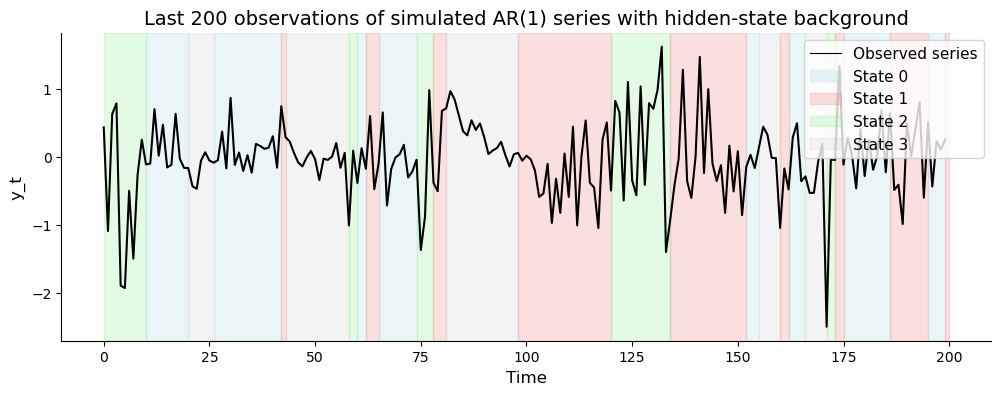

In [33]:

state_colors = {
    0: "lightblue",
    1: "lightcoral",
    2: "lightgreen",
    3: "lightgrey"
}

N = 200
y_plot = y[-N:]
states_plot = states[-N:]
T_plot = len(y_plot)

plt.figure(figsize=(12, 4))
plt.plot(y_plot, color="black", linewidth=1.5, label="Observed series")

start = 0
current_state = states_plot[0]

for t in range(1, T_plot):
    if states_plot[t] != current_state:
        plt.axvspan(start, t, color=state_colors[current_state], alpha=0.25)
        start = t
        current_state = states_plot[t]

plt.axvspan(start, T_plot, color=state_colors[current_state], alpha=0.25)

legend_patches = [
    mpatches.Patch(color=state_colors[0], alpha=0.25, label="State 0"),
    mpatches.Patch(color=state_colors[1], alpha=0.25, label="State 1"),
    mpatches.Patch(color=state_colors[2], alpha=0.25, label="State 2"),
    mpatches.Patch(color=state_colors[3], alpha=0.25, label="State 3")
]

plt.legend(handles=[plt.Line2D([0], [0], color="black", label="Observed series")] + legend_patches, loc="upper right")
plt.title("Last 200 observations of simulated AR(1) series with hidden-state background")
plt.xlabel("Time")
plt.ylabel("y_t")
plt.savefig("../plots/simulated_time_series_4_states_combined_plot_last_200_obs.pdf", bbox_inches="tight", format="pdf")

plt.show()

## Estimate parameters

In [34]:
beta0 = np.array([0.1, -0.1, 0.3, 0.6])

sigma0 = np.array([0.0, 0.2, -0.1, 0.1]) 

P0 = np.array([
    [0.5, 0.2, 0.2, 0.1],
    [0.2, 0.5, 0.2, 0.1],
    [0.2, 0.2, 0.5, 0.1],
    [0.1, 0.2, 0.2, 0.5]
])

# Estimate model:
result, params_hat = fit_model(y, beta0, sigma0, P0)

# Print optimization info:
print("Converged:", result.success)



Converged: True


In [35]:
# Compare estimates with true parameters:
true_params = {
    "beta": beta,
    "sigma": sigma,
    "P": P
}

pred_params = {
    "beta": params_hat["beta"],
    "sigma": params_hat["sigma"],
    "P": params_hat["P"]
}

comparison = pd.DataFrame({
    "true": true_params,
    "estimated": pred_params
})
print("\nComparison table:")
# print(true_params)
# print(params_hat)
# print(pred_params)
display(comparison)
print(P)
print(np.round(params_hat["P"], 4))


Comparison table:


,true,estimated
beta,"[-0.3, 0.0, 0.4, 0.8]","[-0.35091541333252957, -0.04616739608572715, 0..."
sigma,"[0.3, 0.6, 1.0, 0.2]","[0.2767356806357511, 0.5216818448808487, 0.194..."
P,"[[0.9, 0.05, 0.03, 0.02], [0.1, 0.8, 0.05, 0.0...","[[0.9013333080518957, 0.0036708274069415297, 0..."


[[0.9  0.05 0.03 0.02]
 [0.1  0.8  0.05 0.05]
 [0.05 0.1  0.8  0.05]
 [0.02 0.03 0.05 0.9 ]]
[[9.013e-01 3.700e-03 5.200e-03 8.980e-02]
 [6.320e-02 8.877e-01 1.160e-02 3.760e-02]
 [1.000e-04 3.670e-02 9.305e-01 3.280e-02]
 [2.430e-02 1.598e-01 9.250e-02 7.234e-01]]
